In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

In [5]:
# --- 1. Data Preparation ---
df = pd.read_csv('/content/heart_disease.csv')

In [6]:
# --- 2. Exploratory Data Analysis (EDA) ---
# Handle missing values: Fill 'oldpeak' with median
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].median())

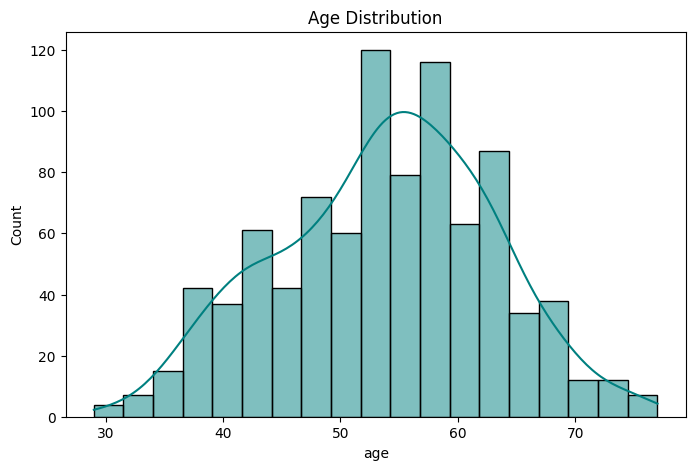

In [7]:
# Visualize distributions
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], kde=True, color='teal')
plt.title('Age Distribution')
plt.show()

In [8]:

# --- 3. Feature Engineering ---
# Convert multiclass target 'num' (0-4) to binary 'target' (0: No Disease, 1: Disease)
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
df_final = df.drop(['num'], axis=1)

In [9]:
# Encode categorical variables using Label Encoding
le = LabelEncoder()
cat_cols = ['sex', 'cp', 'restecg', 'exang', 'slope', 'thal', 'fbs']
for col in cat_cols:
    df_final[col] = le.fit_transform(df_final[col].astype(str))

In [10]:
# --- 4. Decision Tree Classification ---
X = df_final.drop('target', axis=1)
y = df_final['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# --- 5. Hyperparameter Tuning ---
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

In [12]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Best Parameters:", grid_search.best_params_)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")


Best Parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}
Accuracy: 0.7802
Precision: 0.7732
Recall: 0.8065
ROC-AUC: 0.8464


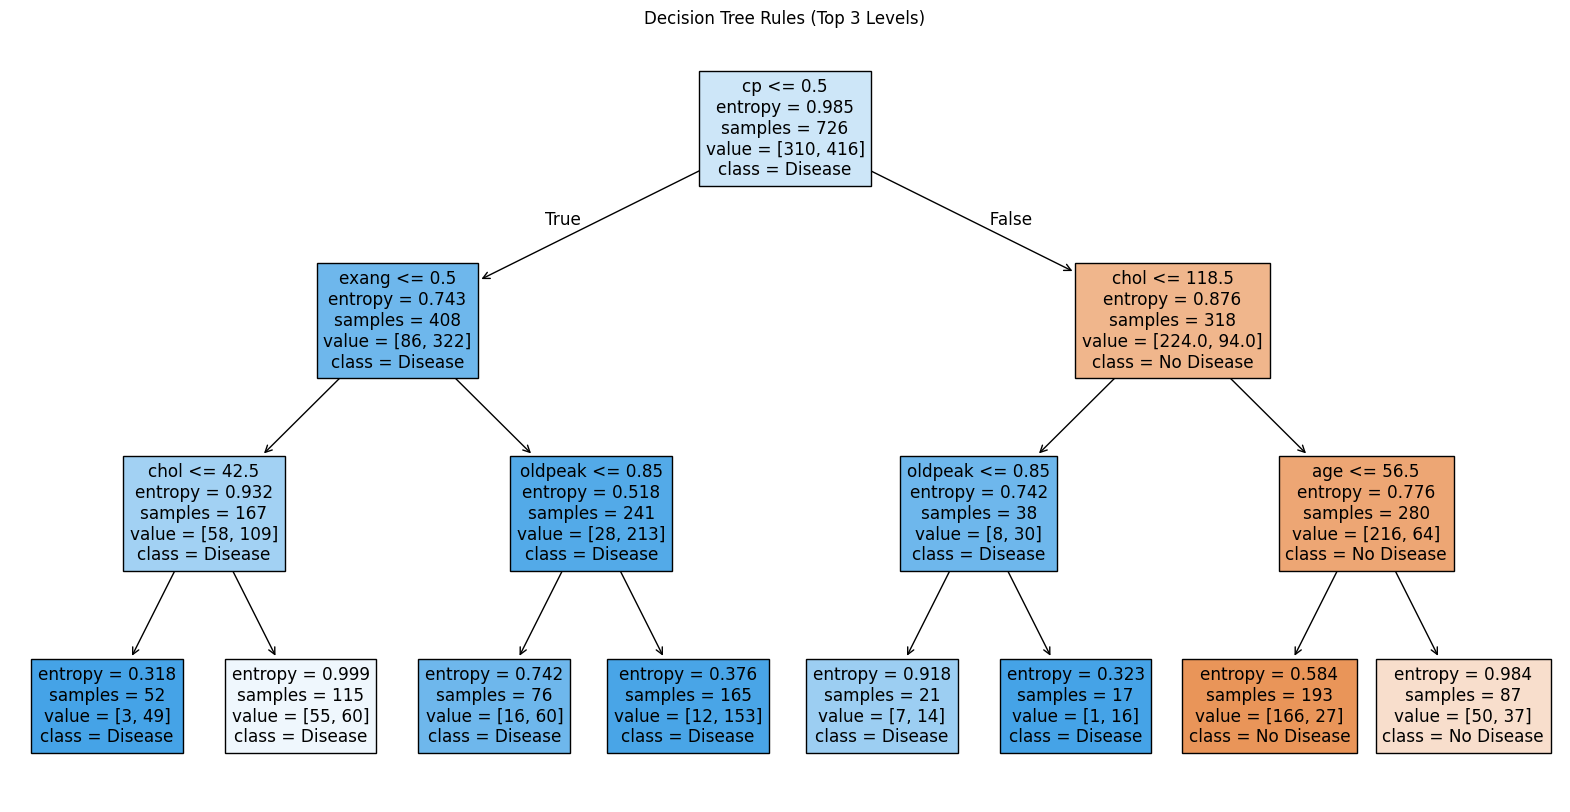

In [13]:
# Visualize the rules learned
plt.figure(figsize=(20, 10))
plot_tree(best_model, feature_names=X.columns, class_names=['No Disease', 'Disease'], filled=True, max_depth=3)
plt.title('Decision Tree Rules (Top 3 Levels)')
plt.show()

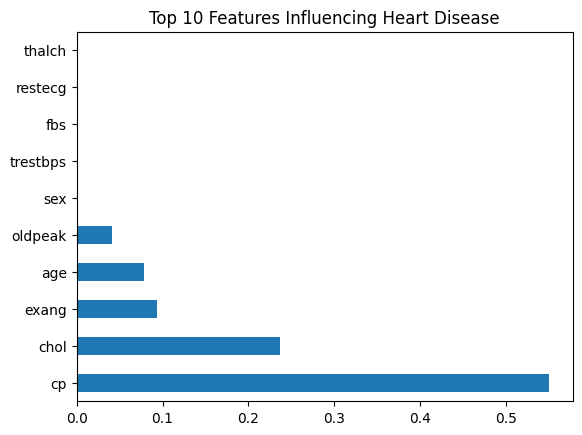

In [14]:
# Feature Importance
feat_importances = pd.Series(best_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Features Influencing Heart Disease')
plt.show()